# **When AI Learns to Think Like Humans**
You might think that AI just needs data to answer any question. In reality, **whether it's a small or large model**, it's not that simple. AIs that **only process blindly, without sequential reasoning**, are at risk of giving **wrong or awkward answers to complex problems**.

Small AI, with limited data or few parameters, lacks intuition and planning ability. Large AI, despite having enormous knowledge, can still **make similar mistakes** if it only relies on data without 'thinking' like humans.

That is why reasoning methods like **Chain-of-Thought**, **Few-Shot**, and **Self-Consistency** become important. They help AI **simulate human thinking**, generate logical solving steps, check results, reduce errors, and improve answer quality.

Therefore, we will try some methods to force the model to simulate human thinking and compare the effectiveness.

## About the Dataset

In this notebook, we use **GSM8K** to evaluate AI reasoning ability.

**GSM8K** consists of ~8,500 grade school math problems. Key features:
- **Multi-step problems**: sequential reasoning required, not just simple calculation
- **Variety of types**: arithmetic, logic, "theory + practice" problems
- **Reasoning evaluation**: correct answers require building explanatory steps first — ideal for testing CoT, Self-Consistency, and MCTS

In [354]:
!pip install datasets litellm matplotlib nest_asyncio -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: D:\Users\nhatt\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [355]:
from datasets import load_dataset
import pandas as pd, re, os, math, time, json, random
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

dataset = load_dataset('gsm8k', 'main')
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['question', 'answer'],
        num_rows: 7473
    })
    test: Dataset({
        features: ['question', 'answer'],
        num_rows: 1319
    })
})


In [356]:
def gsm8k_to_dataframe(num_examples=20):
    data = []
    for i in range(num_examples):
        q = dataset['test'][i]['question']
        a = dataset['test'][i]['answer']
        m = re.findall(r'#### (\d+)', a)
        data.append({'question': q, 'true_answer': m[0] if m else a.strip()})
    return pd.DataFrame(data)

In this session, I will take 20 random data samples from the dataset to test the evaluations

You can try to test with more samples if you have enought token:)

In [357]:
df_test = gsm8k_to_dataframe(num_examples=20).sample(frac=1, random_state=42).reset_index(drop=True) #edit the number of sample you want to take here
print(df_test[['question','true_answer']])

                                             question true_answer
0   Janet’s ducks lay 16 eggs per day. She eats th...          18
1   Jill gets paid $20 per hour to teach and $30 t...       57500
2   A merchant wants to make a choice of purchase ...         125
3   A robe takes 2 bolts of blue fiber and half th...           3
4   John drives for 3 hours at a speed of 60 mph a...          45
5   Kylar went to the store to buy glasses for his...          64
6   Toula went to the bakery and bought various ty...         694
7   James decides to run 3 sprints 3 times a week....         540
8   Claire makes a 3 egg omelet every morning for ...           7
9   Two trains leave San Rafael at the same time. ...         230
10  Melanie is a door-to-door saleswoman. She sold...          18
11  Josh decides to try flipping a house.  He buys...       70000
12  Eliza's rate per hour for the first 40 hours s...         460
13  Marissa is hiking a 12-mile trail. She took 1 ...           6
14  Every 

## Initialize LLM

> **Security note:** Set your API key via environment variable, not hardcoded in source.

In this notebook, I will use the deepseek-chat model (an AI model without reasoning) to experiment with methods

In [ ]:
from litellm import completion, acompletion
import asyncio, nest_asyncio
nest_asyncio.apply()

api_key = os.environ.get('API_KEY', 'YOUR_API_KEY')

def call_llm(messages, model='deepseek/deepseek-chat', max_tokens=1000):
    res = completion(model=model, messages=messages,
                     max_tokens=max_tokens, api_key=api_key)
    return res['choices'][0]['message']['content'], res.usage.total_tokens

async def call_llm_async(messages, model='deepseek/deepseek-chat', max_tokens=1000):
    res = await acompletion(model=model, messages=messages,
                            max_tokens=max_tokens, api_key=api_key)
    return res['choices'][0]['message']['content'], res.usage.total_tokens


## Shared Utilities
Used by all methods below.

In [359]:
import sys
from collections import deque

class LimitedOutput:
    """
    Context manager that keeps the first `head` and last `tail` lines of stdout.
    Middle lines are replaced with a single separator showing how many were hidden.
    """
    def __init__(self, head: int = 15, tail: int = 15):
        self.head          = head
        self.tail          = tail
        self._real_stdout  = None
        self._head_lines   = []
        self._tail_buf     = deque(maxlen=tail)
        self._total        = 0

    def _write(self, text: str):
        for chunk in text.splitlines(keepends=True):
            if not chunk:
                continue
            self._total += 1
            if self._total <= self.head:
                self._head_lines.append(chunk)
            else:
                self._tail_buf.append(chunk)

    def __enter__(self):
        self._real_stdout = sys.stdout
        proxy = self
        class _Proxy:
            write = lambda s, t: proxy._write(t)
            flush = lambda s:    proxy._flush()
        sys.stdout = _Proxy()
        return self

    def __exit__(self, *_):
        sys.stdout = self._real_stdout
        for line in self._head_lines:
            self._real_stdout.write(line)
        hidden = self._total - self.head - len(self._tail_buf)
        if hidden > 0:
            self._real_stdout.write(
                f'\n...{hidden} lines hidden '
                f'(showing first {self.head} + last {len(self._tail_buf)}) ...\n\n'
            )
        for line in self._tail_buf:
            self._real_stdout.write(line)


In [360]:
def extract_number(text):
    """Extract final numeric answer from LLM output."""
    m = re.search(r'Final\s+Answer\s*[:\-]\s*([-+]?\d+(?:[.,]\d+)?)', text, re.I)
    if m: return m.group(1).replace(',', '')
    nums = re.findall(r'[-+]?\d+(?:\.\d+)?', text)
    return nums[-1] if nums else None

COT_SYSTEM = (
    'Solve the problem by thinking step by step naturally. '
    'When done, write your final answer on a new line as:\n'
    'Final Answer: <number only>'
)

def build_prompt_cot(question):
    return [
        {'role': 'system', 'content': COT_SYSTEM},
        {'role': 'user',   'content': f'Question: {question}\nSolution:'},
    ]

def sep(char='─', n=60): print(char * n)

## 1. Chain-of-Thought (CoT)

**Chain-of-Thought (CoT)** helps AI solve problems by **thinking step by step** instead of answering immediately.

**How it works:**
- The model writes out its full reasoning process naturally
- Concludes with `Final Answer: <number>`

First — **without** CoT (direct answer, no reasoning):

In [361]:
def build_prompt_direct(question):
    return [
        {'role': 'system', 'content': 'Answer directly. End with:\nFinal Answer: <number only>'},
        {'role': 'user',   'content': f'Question: {question}\nAnswer:'},
    ]

print('=' * 60)
print('DIRECT (no reasoning)')
print('=' * 60)
res_direct = []
with LimitedOutput(head=15, tail=10):
    for i, row in df_test.iterrows():
        text, _ = call_llm(build_prompt_direct(row['question']), max_tokens=80)
        pred     = extract_number(text)
        correct  = str(pred).strip() == str(row['true_answer']).strip()
        res_direct.append(int(correct))
        mark = '✓' if correct else '✗'
        print(f'[{i+1:02d}] {mark}  Pred={str(pred):<8} GT={row["true_answer"]}')

acc_direct = sum(res_direct) / len(res_direct)
print(f'\n{"="*60}')
print(f'Direct Accuracy: {sum(res_direct)}/{len(res_direct)} = {acc_direct:.1%}')

DIRECT (no reasoning)
[01] ✓  Pred=18       GT=18
[02] ✗  Pred=500      GT=57500
[03] ✓  Pred=125      GT=125
[04] ✓  Pred=3        GT=3
[05] ✗  Pred=4        GT=45
[06] ✗  Pred=5        GT=64
[07] ✗  Pred=330      GT=694
[08] ✓  Pred=540      GT=540
...15 lines hidden (showing first 15 + last 10) ...

[16] ✗  Pred=4        GT=13
[17] ✗  Pred=40       GT=160
[18] ✗  Pred=180      GT=366
[19] ✗  Pred=3        GT=60
[20] ✓  Pred=260      GT=260

Direct Accuracy: 7/20 = 35.0%


Now — **with** CoT (step-by-step reasoning):

In [362]:
def cot(question, total_token_budget=1000, verbose=True):
    t0 = time.perf_counter()
    messages = build_prompt_cot(question)
    text, tokens = call_llm(messages, max_tokens=total_token_budget)
    answer  = extract_number(text)
    latency = round(time.perf_counter() - t0, 2)
    if verbose:
        print('  ---Reasoning-----')
        for line in text.strip().split('\n'):
            print(f'  │ {line}')
        print('  --------')
    return {'method': 'CoT', 'final': answer, 'text': text,
            'tokens_used': tokens, 'latency': latency}

print('=' * 60)
print('CoT  (Chain-of-Thought)')
print('=' * 60)
results_cot = []
with LimitedOutput(head=20, tail=10):
    for i, row in df_test.iterrows():
        result  = cot(row['question'], total_token_budget=1000, verbose=False)
        correct = str(result['final']).strip() == str(row['true_answer']).strip()
        results_cot.append({**result, 'correct': int(correct),
                            'question': row['question'], 'true_answer': row['true_answer']})
        mark = '✓' if correct else '✗'
        print(f'[{i+1:02d}] {mark}  Pred={str(result["final"]):<8} GT={row["true_answer"]:<8}'
              f' | {result["tokens_used"]} tok | {result["latency"]}s')

acc_cot = sum(r['correct'] for r in results_cot) / len(results_cot)
print(f'{"="*60}')
print(f'CoT Accuracy: {sum(r["correct"] for r in results_cot)}/{len(results_cot)} = {acc_cot:.1%}')

CoT  (Chain-of-Thought)
[01] ✗  Pred=12       GT=18       | 228 tok | 4.63s
[02] ✓  Pred=57500    GT=57500    | 280 tok | 6.19s
[03] ✓  Pred=125      GT=125      | 308 tok | 6.92s
[04] ✓  Pred=3        GT=3        | 151 tok | 3.48s
[05] ✓  Pred=45       GT=45       | 536 tok | 12.21s
[06] ✓  Pred=64       GT=64       | 356 tok | 8.47s
[07] ✓  Pred=694      GT=694      | 184 tok | 3.49s
[08] ✓  Pred=540      GT=540      | 143 tok | 3.37s
[09] ✓  Pred=7        GT=7        | 170 tok | 4.4s
[10] ✓  Pred=230      GT=230      | 234 tok | 5.52s

...10 lines hidden (showing first 20 + last 10) ...

[16] ✗  Pred=12       GT=13       | 508 tok | 12.99s
[17] ✓  Pred=160      GT=160      | 371 tok | 9.31s
[18] ✓  Pred=366      GT=366      | 215 tok | 4.45s
[19] ✓  Pred=60       GT=60       | 276 tok | 6.17s
[20] ✓  Pred=260      GT=260      | 221 tok | 4.83s
CoT Accuracy: 18/20 = 90.0%


### Limitations of Chain-of-Thought
- **One wrong step → entire chain fails** — errors cascade forward
- **"Plausible but wrong"** — confident-sounding but incorrect reasoning
- **Prompt-dependent** — poor framing leads AI off-track
- **Single path** — commits to first direction with no backtracking

## 2. Self-Consistency

**Self-Consistency** runs CoT **multiple times** and takes **majority vote** as the final answer.

- Same `total_token_budget`, split equally across `n_votes` calls
- More robust — random errors tend to cancel out

In [363]:
async def _cot_self_consistency_async(question, n_votes=3, total_token_budget=1000):
    budget_per_call = total_token_budget // n_votes
    t0 = time.perf_counter()
    tasks = [call_llm_async(build_prompt_cot(question), max_tokens=budget_per_call)
             for _ in range(n_votes)]
    results = await asyncio.gather(*tasks)

    answers, tokens_total = [], 0
    for text, tok in results:
        tokens_total += tok
        ans = extract_number(text)
        if ans:
            answers.append(ans)

    latency = round(time.perf_counter() - t0, 2)
    if not answers:
        return {'method': 'Self-Consistency', 'final': None, 'confidence': 0.0,
                'tokens_used': tokens_total, 'latency': latency}
    dist = Counter(answers)
    best, count = dist.most_common(1)[0]
    return {'method': 'Self-Consistency', 'final': best,
            'confidence':   round(count / len(answers), 3),
            'distribution': dict(dist),
            'tokens_used':  tokens_total,
            'latency':      latency}

def cot_self_consistency(question, n_votes=3, total_token_budget=1000, verbose=True):
    return asyncio.get_event_loop().run_until_complete(
        _cot_self_consistency_async(question, n_votes, total_token_budget))

In [364]:
print('=' * 60)
print('Self-Consistency  (3 votes)')
print('=' * 60)
results_sc = []
with LimitedOutput(head=20, tail=10):
    for i, row in df_test.iterrows():
        result  = cot_self_consistency(row['question'], n_votes=3,
                                        total_token_budget=1000, verbose=False)
        correct = str(result['final']).strip() == str(row['true_answer']).strip()
        results_sc.append({**result, 'correct': int(correct),
                           'question': row['question'], 'true_answer': row['true_answer']})
        mark = '✓' if correct else '✗'
        conf = result.get('confidence', 0)
        dist_str = str(result.get('distribution', {}))
        print(f'[{i+1:02d}] {mark}  Final={str(result["final"]):<8} GT={row["true_answer"]:<8}'
              f' conf={conf:.0%}  votes={dist_str}')

acc_sc = sum(r['correct'] for r in results_sc) / len(results_sc)
print(f'{"="*60}')
print(f'Self-Consistency Accuracy: {sum(r["correct"] for r in results_sc)}/{len(results_sc)} = {acc_sc:.1%}')

Self-Consistency  (3 votes)
[01] ✓  Final=18       GT=18       conf=67%  votes={'18': 2, '12': 1}
[02] ✓  Final=57500    GT=57500    conf=100%  votes={'57500': 3}
[03] ✓  Final=125      GT=125      conf=100%  votes={'125': 3}
[04] ✓  Final=3        GT=3        conf=100%  votes={'3': 3}
[05] ✗  Final=120      GT=45       conf=67%  votes={'120': 2, '1.5': 1}
[06] ✓  Final=64       GT=64       conf=100%  votes={'64': 3}
[07] ✓  Final=694      GT=694      conf=100%  votes={'694': 3}
[08] ✓  Final=540      GT=540      conf=100%  votes={'540': 3}
[09] ✓  Final=7        GT=7        conf=100%  votes={'7': 3}
[10] ✓  Final=230      GT=230      conf=100%  votes={'230': 3}

...10 lines hidden (showing first 20 + last 10) ...

[16] ✗  Final=7        GT=13       conf=67%  votes={'13': 1, '7': 2}
[17] ✓  Final=160      GT=160      conf=67%  votes={'160': 2, '100': 1}
[18] ✓  Final=366      GT=366      conf=100%  votes={'366': 3}
[19] ✓  Final=60       GT=60       conf=100%  votes={'60': 3}
[20] ✓  F

### Limitations
- **Majority wrong → still wrong** — shared systematic errors aren't caught
- **No explanation** — hard to understand why majority chose an answer
- **Budget split** — each vote gets fewer tokens than single CoT

## 3. Best-of-N

**Best-of-N** generates N independent answers, scores each with the model, picks the highest-scoring one.

- 80% of budget → generation, 20% → scoring
- Better when answers are all different (no clear majority)

In [365]:
def build_prompt_verify(question, answer, reasoning):
    return [
        {'role': 'system', 'content': (
            'You are an expert logical verifier. You DO NOT know the true answer.\n'
            'Your task is to score the solution from 0.0 to 1.0 based ONLY on logical consistency and arithmetic accuracy.\n'
            'Deduct points heavily if there are logical leaps, contradictions, missing steps, or mathematical calculation errors.\n'
            'If the steps perfectly justify the final answer, give a high score.\n'
            'Return ONLY a float number.'
        )},
        {'role': 'user', 'content':
            f'Question: {question}\n\nReasoning:\n{reasoning}\n\nFinal Answer: {answer}'},
    ]

async def _cot_best_of_n_async(question, n=3, total_token_budget=1000, verbose=False):
    gen_budget   = int(total_token_budget * 0.8) // n
    score_budget = max(20, int(total_token_budget * 0.2) // n)
    t0 = time.perf_counter()

    gen_results = await asyncio.gather(
        *[call_llm_async(build_prompt_cot(question), max_tokens=gen_budget) for _ in range(n)])

    tokens_total = sum(tok for _, tok in gen_results)
    valid = [(text, extract_number(text)) for text, _ in gen_results if extract_number(text)]

    score_results = await asyncio.gather(
        *[call_llm_async(build_prompt_verify(question, ans, text), max_tokens=score_budget)
          for text, ans in valid])

    candidates = []
    for (text, answer), (score_text, tok_s) in zip(valid, score_results):
        tokens_total += tok_s
        try:
            score = float(re.search(r'\d+\.?\d*', score_text).group())
            score = min(max(score, 0.0), 1.0)
        except:
            score = 0.0
        candidates.append({'answer': answer, 'score': score, 'text': text})
        if verbose:
            print(f'    Candidate {len(candidates)}: ans={str(answer):<8} score={score:.2f}')

    latency = round(time.perf_counter() - t0, 2)
    if not candidates:
        return {'method': 'Best-of-N', 'final': None, 'best_score': 0.0,
                'tokens_used': tokens_total, 'latency': latency}
    best = max(candidates, key=lambda x: x['score'])
    return {'method': 'Best-of-N', 'final': best['answer'],
            'best_score': best['score'], 'all_scores': [c['score'] for c in candidates],
            'tokens_used': tokens_total, 'latency': latency}

def cot_best_of_n(question, n=3, total_token_budget=1000, verbose=False):
    return asyncio.get_event_loop().run_until_complete(
        _cot_best_of_n_async(question, n, total_token_budget, verbose))


In [366]:
print('=' * 60)
print('Best-of-N  (n=3)')
print('=' * 60)
results_bon = []
with LimitedOutput(head=20, tail=10):
    for i, row in df_test.iterrows():
        result  = cot_best_of_n(row['question'], n=3, total_token_budget=1000, verbose=False)
        correct = str(result['final']).strip() == str(row['true_answer']).strip()
        results_bon.append({**result, 'correct': int(correct),
                            'question': row['question'], 'true_answer': row['true_answer']})
        mark = '✓' if correct else '✗'
        print(f'[{i+1:02d}] {mark}  Final={str(result["final"]):<8} GT={row["true_answer"]:<8}'
              f' best_score={result.get("best_score",0):.2f}')

acc_bon = sum(r['correct'] for r in results_bon) / len(results_bon)
print(f'{"="*60}')
print(f'Best-of-N Accuracy: {sum(r["correct"] for r in results_bon)}/{len(results_bon)} = {acc_bon:.1%}')

Best-of-N  (n=3)
[01] ✓  Final=18       GT=18       best_score=1.00
[02] ✓  Final=57500    GT=57500    best_score=1.00
[03] ✓  Final=125      GT=125      best_score=0.90
[04] ✓  Final=3        GT=3        best_score=1.00
[05] ✗  Final=4        GT=45       best_score=0.00
[06] ✓  Final=64       GT=64       best_score=1.00
[07] ✓  Final=694      GT=694      best_score=1.00
[08] ✓  Final=540      GT=540      best_score=1.00
[09] ✓  Final=7        GT=7        best_score=1.00
[10] ✓  Final=230      GT=230      best_score=0.00

...10 lines hidden (showing first 20 + last 10) ...

[16] ✗  Final=12       GT=13       best_score=0.80
[17] ✗  Final=20       GT=160      best_score=0.00
[18] ✓  Final=366      GT=366      best_score=1.00
[19] ✓  Final=60       GT=60       best_score=0.90
[20] ✓  Final=260      GT=260      best_score=1.00
Best-of-N Accuracy: 15/20 = 75.0%


### Limitations
- **Self-assessment bias** — LLM tends to inflate scores for confident-sounding (but wrong) answers
- **Higher cost** — generation + scoring overhead per candidate
- **"Confidently wrong"** — no guarantee high score = correct answer

## Problems with the Above Methods

All three methods share a fundamental limitation:

> They are **independent trials** — each run starts fresh with no memory of what failed before. They cannot **backtrack** or **reuse promising partial reasoning**.

- **CoT**: linear, one shot
- **Self-Consistency**: independent — doesn't reuse good partial reasoning
- **Best-of-N**: picks best independent attempt — no incremental refinement

## MCTS (Monte Carlo Tree Search): Strategic Reasoning Exploration

You may have heard about AlphaGo defeating the world's top Go players. One of its core techniques is **Monte Carlo Tree Search (MCTS)**.

AlphaGo didn't just memorize moves — it **proactively explored and evaluated different possibilities before deciding**.

Applied to LLMs, MCTS:
- **Builds a reasoning tree** — partial solutions become branches to explore
- **Tries different paths** — multiple directions tested from each node
- **Evaluates each step** — scores guide which branches deserve more expansion
- **Reuses good partial reasoning** — promising starts are extended, bad starts abandoned

### UCB1 — The Heart of MCTS

UCB1 decides which node to visit next, balancing **exploit** (high value) vs **explore** (less visited):

$$UCB1(node) = \frac{Q(node)}{N(node)} + c \cdot \sqrt{\frac{\ln N(parent)}{N(node)}}$$

- $Q/N$: average reward → **exploit**
- Square root term: exploration bonus, decreases as node is visited more
- $c = 1.4$ (tune 0.5–2.0 for language tasks)

### 4 Repeating Steps

| Step | Action | LLM Role |
|---|---|---|
| **Selection** | Follow UCB1 to best leaf | — |
| **Expansion** | Generate k next reasoning steps | Policy: generate candidates |
| **Rollout (Simulation)** | Complete solution from leaf | Generate full answer |
| **Backprop** | Update scores up the tree | — |

------------------------------------------------------------

![4 Repeating Steps](images\simulate.png)


-------------------------------------------------------------


| MCTS concept | LLM equivalent |
|---|---|
| State | Current prompt + reasoning so far |
| Action | Next reasoning step (LLM-generated) |
| Simulation | Full solution completion |
| Reward | Evaluator score (0-1) |

In [367]:
class Node:
    def __init__(self, state, parent=None, step_text='[root]'):
        self.state      = state
        self.step_text  = step_text
        self.parent     = parent
        self.children   = []
        self.visits     = 0
        self.value      = 0.0
        self.rollout_scores = []

    def is_leaf(self):
        return len(self.children) == 0

    def avg_value(self):
        return self.value / self.visits if self.visits else 0.0

    def ucb_score(self, c=1.4):
        if self.visits == 0:
            return float('inf')
        if self.parent is None or self.parent.visits == 0:
            return self.avg_value()
        return self.avg_value() + c * math.sqrt(
            math.log(self.parent.visits) / self.visits
        )

    def __repr__(self):
        return (f"Node(visits={self.visits}, avg={self.avg_value():.2f}, "
                f"step='{self.step_text[:40]}...')")

In [368]:
def select(node):
    """Traverse tree following UCB1 until a leaf is reached. Returns (leaf, path)."""
    path = [node]
    while not node.is_leaf():
        node = max(node.children, key=lambda n: n.ucb_score())
        path.append(node)
    return node, path

In [369]:
async def _expand_async(node, question, k=2):
    """LLM generates k distinct next reasoning steps in parallel."""
    async def gen_step():
        messages = [
            {'role': 'system', 'content': (
                'You are solving a math problem step by step.\n'
                'Generate ONLY the NEXT single reasoning step (1-2 sentences, ~30-60 words).\n'
                'Be concrete: state the specific calculation or logical deduction.\n'
                'Do NOT write a full solution. Do NOT repeat earlier steps.\n'
                'Your step must explore a DISTINCT approach from any siblings listed.'
            )},
            {'role': 'user', 'content': (
                f'Question: {question}\n\nReasoning so far:\n{node.state}\n\nNext single step:'
            )},
        ]
        text, _ = await call_llm_async(messages, max_tokens=80)
        return text.strip()

    steps = await asyncio.gather(*[gen_step() for _ in range(k)])

    children, seen = [], []
    for step in steps:
        if any(similar(step, s) for s in seen):
            continue
        seen.append(step)
        child = Node(node.state + '\nStep: ' + step, parent=node, step_text=step)
        node.children.append(child)
        children.append(child)
    return children

def expand(node, question, k=2):
    return asyncio.get_event_loop().run_until_complete(_expand_async(node, question, k))

def similar(a, b, threshold=0.7):
    a_words, b_words = set(a.lower().split()), set(b.lower().split())
    if not a_words or not b_words:
        return False
    return len(a_words & b_words) / len(a_words | b_words) > threshold


In [370]:
async def _rollout_async(node, question):
    """Complete solution from this node's partial reasoning."""
    messages = [
        {'role': 'system', 'content': COT_SYSTEM},
        {'role': 'user', 'content': (
            f'Question: {question}\n\nReasoning so far:\n{node.state}\n\n'
            'Continue reasoning and give the final answer:'
        )},
    ]
    return await call_llm_async(messages, max_tokens=400)

def rollout(node, question):
    return asyncio.get_event_loop().run_until_complete(_rollout_async(node, question))


In [371]:
async def _evaluate_async(output, question):
    """Score a completed reasoning+answer (0.0-1.0)"""
    if extract_number(output) is None:
        return 0.05, ''
    messages = [
        {'role': 'system', 'content': (
            'You are an expert logical verifier. You DO NOT know the final answer to the problem.\n'
            'First list any errors you find (logical gaps, wrong arithmetic). '
            'If you find NO errors, explain why each step is correct. '
            'Then give your score. Scores above 0.8 require zero errors found.'
            'Evaluate the provided solution based strictly on internal logic and mathematical rules using this rubric:\n'
            '  0.9-1.0: Flawless logic. Every step follows clearly from the previous one, and all arithmetic is correct.\n'
            '  0.6-0.8: Mostly logical, but contains minor leaps or relies on unstated assumptions. Math calculations appear correct.\n'
            '  0.3-0.5: Noticeable logical gaps or minor arithmetic errors that skew the final result.\n'
            '  0.0-0.2: Fundamentally flawed reasoning, contradictory statements, or obvious calculation errors.\n'
            'CRITICAL: Step through the logic carefully before scoring. Do not guess the answer, just verify the process.\n'
            'Return ONLY valid JSON: {"score": <0.0-1.0>, "reason": "<one sentence explanation>"}'
        )},
        {'role': 'user', 'content': (
            f'Question: {question}\n\nSolution to verify:\n{output}\n\nVerification Grade:'
        )},
    ]
    response, _ = await call_llm_async(messages, max_tokens=80)
    try:
        cleaned = response.strip()
        if '```' in cleaned:
            cleaned = cleaned.split('\n', 1)[1].rsplit('```', 1)[0]
        data  = json.loads(cleaned)
        score = float(data['score'])
        return min(max(score, 0.0), 1.0), data.get('reason', '')
    except:
        try:
            score = float(re.search(r'\d+\.?\d*', response).group())
            return min(max(score / (10 if score > 1 else 1), 0.0), 1.0), ''
        except:
            return 0.1, ''

def evaluate(output, question):
    return asyncio.get_event_loop().run_until_complete(_evaluate_async(output, question))


In [372]:
def backpropagate(node, reward):
    while node:
        node.visits += 1
        node.value  += reward
        node = node.parent

In [373]:
async def _mcts_async(problem, question, iterations=10, k=2, max_depth=4, verbose=True):
    t0 = time.perf_counter()
    root = Node(problem, step_text='[root]')
    tokens_total = 0

    if verbose:
        print(f' -------Tree search starting  (iterations={iterations}, k={k}, max_depth={max_depth})')

    for it in range(iterations):
        if verbose:
            print(f'  Iteration {it+1}/{iterations}-----------')

        # 1. Selection
        leaf, path = select(root)
        depth = len(path) - 1
        if verbose:
            print(f'     [Select]  leaf_depth={depth}  '
                  f'leaf_visits={leaf.visits}  leaf_avg={leaf.avg_value():.2f}')

        # 2. Expansion — k steps song song
        if leaf.visits > 0 and depth < max_depth:
            children = await _expand_async(leaf, question, k=k)
            if verbose:
                for ci, child in enumerate(children):
                    snippet = child.step_text[:65].replace('\n', ' ')
                    print(f'     [Expand {ci+1}]  "{snippet}"')
        else:
            children = [leaf]
            if verbose:
                reason = 'depth limit reached' if depth >= max_depth else 'first visit — rollout before expanding'
                print(f'     [No expand: {reason}]')

        # 3. Rollout + Evaluate — tất cả children song song
        async def rollout_and_eval(child):
            output, tok = await _rollout_async(child, question)
            reward, reason = await _evaluate_async(output, question)
            return output, tok, reward, reason

        eval_results = await asyncio.gather(*[rollout_and_eval(c) for c in children])

        for child, (output, tok, reward, reason) in zip(children, eval_results):
            tokens_total += tok
            child.rollout_scores.append(reward)
            if verbose:
                ans_found = extract_number(output)
                print(f'     [Rollout] pred={str(ans_found):<8} score={reward:.2f}')
                if reason:
                    print(f'               reason: {reason[:80]}')
            # 4. Backpropagation
            backpropagate(child, reward)

        if verbose and root.children:
            print(f'     [Tree state after iter {it+1}]:')
            def print_tree(node, indent=0):
                prefix = '  ' * indent
                print(f'       {prefix}visits={node.visits}  avg={node.avg_value():.2f}  ucb={node.ucb_score():.2f}  "{node.step_text[:40]}"')
                for ch in node.children:
                    print_tree(ch, indent+1)
            print_tree(root)

    if not root.children:
        return {'method': 'MCTS', 'final': None, 'latency': 0,
                'tokens_used': 0, 'root': root}

    def best_leaf(node):
        if not node.children:
            return node
        return max((best_leaf(c) for c in node.children), key=lambda n: n.avg_value())

    best = best_leaf(root)
    final_text, tok_final = await _rollout_async(best, question)
    tokens_total += tok_final
    final_answer = extract_number(final_text)
    latency      = round(time.perf_counter() - t0, 2)

    if verbose:
        print(f'  Best leaf: visits={best.visits}  avg={best.avg_value():.2f}')
        print(f'  Final answer: {final_answer}  | Latency: {latency}s | Tokens: {tokens_total}')

    return {
        'method':           'MCTS',
        'final':            final_answer,
        'final_text':       final_text,
        'tokens_used':      tokens_total,
        'latency':          latency,
        'total_iterations': iterations,
        'best_node_visits': best.visits,
        'best_avg_value':   round(best.avg_value(), 3),
        'root':             root,
    }

def mcts(problem, question, iterations=10, k=2, max_depth=4, verbose=True):
    return asyncio.get_event_loop().run_until_complete(
        _mcts_async(problem, question, iterations, k, max_depth, verbose))


let's try it

In [374]:
print('=' * 60)
print('MCTS')
print('=' * 60)
results_mcts = []

with LimitedOutput(head=20, tail=15):
    for i, row in df_test.iterrows():
        question = row['question']
        problem  = f'Question: {question}\nLet me think step by step.'

        print(f'\n[{i+1:02d}] Q: {question[:90]}...')
        result  = mcts(problem, question, iterations=20, k=2, verbose=False)
        correct = str(result.get('final')).strip() == str(row['true_answer']).strip()
        r_store = {k: v for k, v in result.items() if k != 'root'}
        r_store['root']        = result['root']
        r_store['correct']     = int(correct)
        r_store['question']    = question
        r_store['true_answer'] = row['true_answer']
        results_mcts.append(r_store)
        mark = '✓' if correct else '✗'
        print(f'  → {mark}  Pred={result.get("final")}  GT={row["true_answer"]}  '
            f'Latency={result.get("latency")}s  Tokens={result.get("tokens_used", 0)}')
        print('=' * 60)

acc_mcts = sum(r['correct'] for r in results_mcts) / len(results_mcts)
print(f'\nMCTS Accuracy: {sum(r["correct"] for r in results_mcts)}/{len(results_mcts)} = {acc_mcts:.1%}')

MCTS

[01] Q: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes mu...
  → ✓  Pred=18  GT=18  Latency=140.58s  Tokens=8546

[02] Q: Jill gets paid $20 per hour to teach and $30 to be a cheerleading coach. If she works 50 w...
  → ✓  Pred=57500  GT=57500  Latency=141.74s  Tokens=7711

[03] Q: A merchant wants to make a choice of purchase between 2 purchase plans: jewelry worth $5,0...
  → ✓  Pred=125  GT=125  Latency=149.06s  Tokens=10149
...105 lines hidden (showing first 20 + last 15) ...



[19] Q: In a dance class of 20 students, 20% enrolled in contemporary dance, 25% of the remaining ...
  → ✓  Pred=60  GT=60  Latency=111.35s  Tokens=7206

[20] Q: Toulouse has twice as many sheep as Charleston. Charleston has 4 times as many sheep as Se...
  → ✓  Pred=260  GT=260  Latency=118.35s  Tokens=7922

MCTS Accuracy: 20/20 = 100.0%


### MCTS Visualization

Render the actual search tree for one example question, showing:
- Node sizes proportional to visit counts
- Colors = avg reward score (red=low, green=high)
- Edge thickness = visit count

In [375]:
from collections import deque
def draw_mcts_tree(root_node, question, true_answer, predicted_answer, ax=None):
    """Draw MCTS search tree với full edges và highlight best path."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(18, 10))

    cmap = cm.RdYlGn

    # 1. Node collect using BFS
    all_nodes = []
    queue = deque([root_node])
    while queue:
        node = queue.popleft()
        all_nodes.append(node)
        for child in node.children:
            queue.append(child)

    # 2. best path
    def find_best_path(node):
        if not node.children:
            return [node]
        best_child = max(node.children, key=lambda n: n.avg_value())
        return [node] + find_best_path(best_child)

    best_path = set(id(n) for n in find_best_path(root_node))

    #3. Layout
    pos = {}

    def layout(node, depth=0, x_start=0.0, x_end=1.0):
        x_mid = (x_start + x_end) / 2
        pos[id(node)] = (x_mid, -depth * 1.4)
        if node.children:
            w = (x_end - x_start) / len(node.children)
            for ci, child in enumerate(node.children):
                layout(child, depth + 1, x_start + ci * w, x_start + (ci + 1) * w)

    layout(root_node)

    # 4. draw edges
    def draw_edges(node):
        px, py = pos[id(node)]
        for child in node.children:
            cx, cy = pos[id(child)]
            on_best = id(node) in best_path and id(child) in best_path
            ax.plot(
                [px, cx], [py, cy],
                color='#E63946' if on_best else '#AAAAAA',
                lw=4.0 if on_best else 1.2,
                alpha=1.0 if on_best else 0.5,
                zorder=2,
                solid_capstyle='round'
            )
            draw_edges(child)

    draw_edges(root_node)

    #5. draw nodes
    for node in all_nodes:
        if id(node) not in pos:
            continue
        x, y    = pos[id(node)]
        avg     = node.avg_value()
        visits  = node.visits
        on_best = id(node) in best_path
        is_root = node.parent is None

        rgba = cmap(avg)
        size = max(100, visits * 100)
        edge_color = '#E63946' if on_best else '#333333'
        edge_lw    = 3.0       if on_best else 0.8

        ax.scatter(x, y, s=size, color=[rgba], zorder=4,
                   edgecolors=edge_color, linewidths=edge_lw)

        # Label
        if is_root:
            label = 'ROOT'
        else:
            snippet = node.step_text[:28].replace('\n', ' ')
            label   = f'{snippet}...\nv={visits} avg={avg:.2f}'
            if on_best:
                label = '* ' + label

        ax.text(x, y - 0.09, label,
                ha='center', va='top', fontsize=6,
                color='#C0392B' if on_best else '#222222',
                fontweight='bold' if on_best else 'normal',
                zorder=5,
                bbox=dict(boxstyle='round,pad=0.15',
                          fc='#FFE5E5' if on_best else 'white',
                          alpha=0.85, ec='none'))

    # 6. Legend best path
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='#E63946', lw=3, label='Best path (highest avg score)'),
        Line2D([0], [0], color='#AAAAAA', lw=1.2, label='Other paths'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.8)

    # 7. Axes & title
    all_pos = list(pos.values())
    xs = [p[0] for p in all_pos]
    ys = [p[1] for p in all_pos]
    ax.set_xlim(min(xs) - 0.05, max(xs) + 0.05)
    ax.set_ylim(min(ys) - 0.6, max(ys) + 0.3)
    ax.axis('off')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Avg Reward Score', shrink=0.5, pad=0.01)

    short_q = question[:75] + ('...' if len(question) > 75 else '')
    mark = '✓' if str(predicted_answer) == str(true_answer) else '✗'
    ax.set_title(
        f'MCTS{mark}\n'
        f'Q: {short_q}\n'
        f'Predicted: {predicted_answer}   Ground Truth: {true_answer}',
        fontsize=9, pad=8
    )



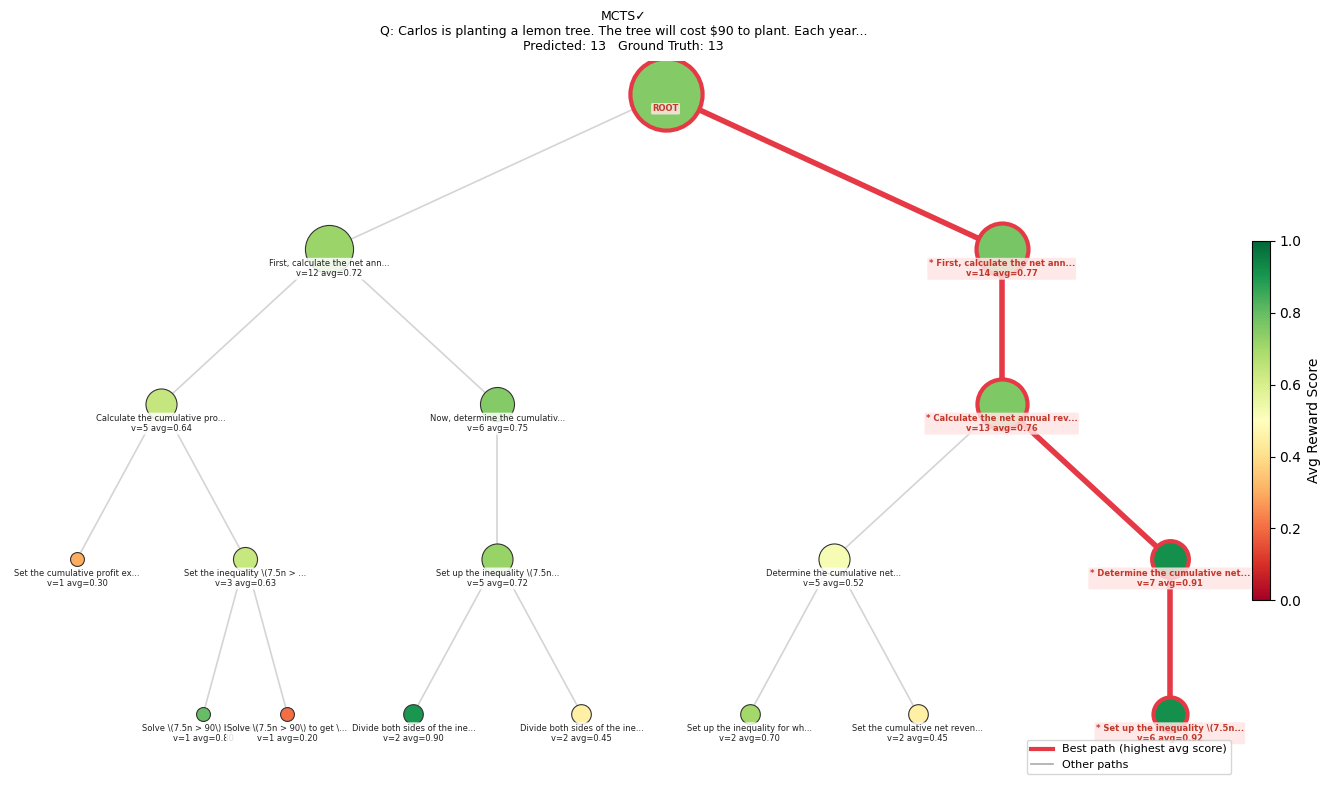

Q1 — Pred: 13  GT: 13  ✓


In [399]:
#visualize tree
r0 = results_mcts[15]  #choose which Q&A you wait to visualize


fig, ax = plt.subplots(figsize=(15, 8))
draw_mcts_tree(r0['root'], r0['question'], r0['true_answer'], r0['final'], ax=ax)
plt.tight_layout()
plt.savefig('mcts_tree_q1.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Q1 — Pred: {r0['final']}  GT: {r0['true_answer']}  {'✓' if r0['correct'] else '✗'}")

If you want to have a deeper tree and more reasoning paths, then increase k and the number of loops and perhaps the accuracy will be much higher but it will consume more tokens

let's look at the best reasoning path

In [400]:
def print_best_path_reasoning(result):
    """show full reasoning text"""
    root = result['root']

    def find_best_path(node):
        if not node.children:
            return [node]
        best = max(node.children, key=lambda n: n.avg_value())
        return [node] + find_best_path(best)

    path = find_best_path(root)

    print('=' * 70)
    print('BEST PATH — Step-by-step reasoning')
    print('=' * 70)
    for i, node in enumerate(path):
        prefix = 'ROOT' if i == 0 else f'Step {i} *'
        print(f'\n[{prefix}]  visits={node.visits}  avg={node.avg_value():.2f}')
        print(f'  {node.step_text}')
        if node.rollout_scores:
            print(f'  Rollout scores: {[round(s,2) for s in node.rollout_scores]}')

    print('\n' + '-' * 70)
    print(f'Final Answer: {result.get("final")}')
    print('-' * 70)
print(r0['question'])
print_best_path_reasoning(r0)

Carlos is planting a lemon tree. The tree will cost $90 to plant. Each year it will grow 7 lemons, which he can sell for $1.5 each. It costs $3 a year to water and feed the tree. How many years will it take before he starts earning money on the lemon tree?
BEST PATH — Step-by-step reasoning

[ROOT]  visits=27  avg=0.75
  [root]
  Rollout scores: [0.9]

[Step 1 *]  visits=14  avg=0.77
  First, calculate the net annual revenue from selling the lemons after subtracting the yearly costs: \(7 \times 1.5 - 3\).
  Rollout scores: [0.9]

[Step 2 *]  visits=13  avg=0.76
  Calculate the net annual revenue: \(7 \times 1.5 = 10.5\), then subtract $3 to get $7.5 per year.
  Rollout scores: [0.9]

[Step 3 *]  visits=7  avg=0.91
  Determine the cumulative net revenue after \(n\) years, which is \(7.5n\), and set up an inequality where this exceeds the initial cost of $90.
  Rollout scores: [0.9]

[Step 4 *]  visits=6  avg=0.92
  Set up the inequality \(7.5n > 90\) to find the smallest integer \(n\) w

compare with CoT reasoning

In [401]:
result_cot_compare  = cot(r0['question'], total_token_budget=1000, verbose=True)
print(result_cot_compare)

  ---Reasoning-----
  │ Let’s break it down step by step.  
  │ 
  │ ---
  │ 
  │ **1. Initial cost to plant the tree**  
  │ Planting cost = $90  
  │ 
  │ ---
  │ 
  │ **2. Annual revenue from lemons**  
  │ Each year: 7 lemons × $1.5 each = $10.5  
  │ 
  │ ---
  │ 
  │ **3. Annual cost to maintain the tree**  
  │ Water and feed = $3 per year  
  │ 
  │ ---
  │ 
  │ **4. Annual profit (revenue − cost)**  
  │ Annual profit = $10.5 − $3 = $7.5 per year  
  │ 
  │ ---
  │ 
  │ **5. Years to recover initial cost**  
  │ Let \( y \) = years until total profit equals initial cost.  
  │ Total profit after \( y \) years = \( 7.5y \)  
  │ 
  │ We want \( 7.5y \ge 90 \) for breaking even (start earning money after breaking even).  
  │ 
  │ \[
  │ 7.5y = 90
  │ \]
  │ \[
  │ y = \frac{90}{7.5} = 12
  │ \]
  │ 
  │ ---
  │ 
  │ **6. Interpretation**  
  │ After 12 years, total profit = initial cost → break-even point.  
  │ He starts earning money **after** the 12th year, so the first year

### Evaluator Score Distribution

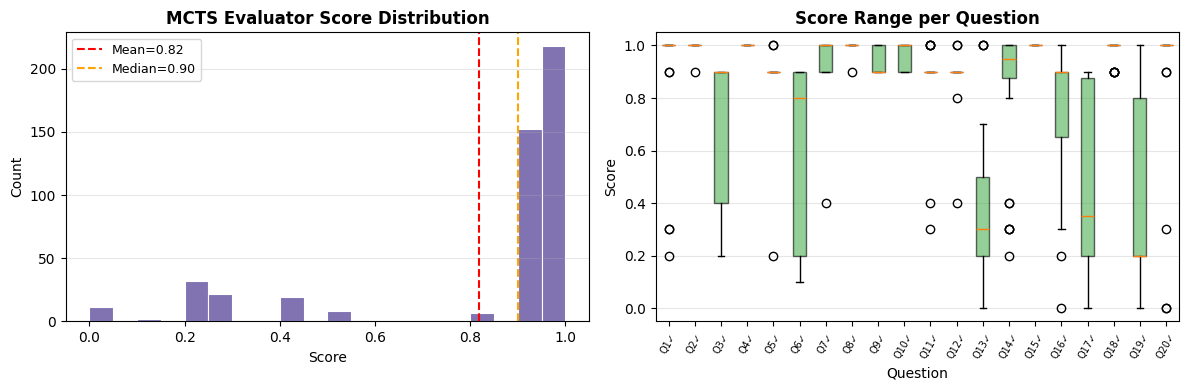

Score stats: mean=0.818  std=0.287  min=0.000  max=1.000


In [379]:
all_scores = []
for r in results_mcts:
    root = r.get('root')
    if root is None: continue
    def collect(node):
        all_scores.extend(node.rollout_scores)
        for c in node.children: collect(c)
    collect(root)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(all_scores, bins=20, range=(0,1), color='#8172B2', edgecolor='white', linewidth=0.8)
ax.axvline(np.mean(all_scores), color='red',    linestyle='--',
            label=f'Mean={np.mean(all_scores):.2f}')
ax.axvline(np.median(all_scores), color='orange', linestyle='--',
            label=f'Median={np.median(all_scores):.2f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count')
ax.set_title('MCTS Evaluator Score Distribution', fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
scores_by_q, labels_by_q = [], []
for qi, r in enumerate(results_mcts):
    root = r.get('root')
    if root is None: continue
    qs = []
    def collect_q(node):
        qs.extend(node.rollout_scores)
        for c in node.children: collect_q(c)
    collect_q(root)
    if qs:
        scores_by_q.append(qs)
        labels_by_q.append(f"Q{qi+1}{'✓' if r['correct'] else '✗'}")

bp = ax.boxplot(scores_by_q, patch_artist=True, labels=labels_by_q)
for patch, r in zip(bp['boxes'], results_mcts):
    patch.set_facecolor('#4CAF50' if r['correct'] else '#F44336')
    patch.set_alpha(0.6)
ax.set_xlabel('Question'); ax.set_ylabel('Score')
ax.set_title('Score Range per Question', fontweight='bold')
ax.tick_params(axis='x', rotation=60, labelsize=7)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('mcts_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Score stats: mean={np.mean(all_scores):.3f}  std={np.std(all_scores):.3f}  '
      f'min={np.min(all_scores):.3f}  max={np.max(all_scores):.3f}')

## Fair Comparison: Token-Normalized Results

**Critical:** MCTS uses many more LLM calls than CoT. Raw accuracy comparison alone is misleading.

We measure four metrics:
1. **Accuracy** — % questions answered correctly
2. **Avg tokens** — total API tokens per question
3. **Avg latency** — wall-clock seconds per question
4. **Tokens per correct** — efficiency: tokens spent to get one right answer

In [380]:
def aggregate(results, label):
    n       = len(results)
    correct = sum(r['correct'] for r in results)
    tokens  = [r.get('tokens_used', 0) for r in results]
    lats    = [r.get('latency', 0) for r in results]
    return {
        'method':        label,
        'n':             n,
        'accuracy':      correct / n,
        'correct':       correct,
        'avg_tokens':    float(np.mean(tokens)),
        'avg_latency':   float(np.mean(lats)),
        'tok_per_correct': float(np.mean(tokens)) / max(correct / n, 1e-6),
    }

stats = [
    aggregate(results_cot,  'CoT'),
    aggregate(results_sc,   'Self-Consistency'),
    aggregate(results_bon,  'Best-of-N'),
    aggregate(results_mcts, 'MCTS'),
]
df_stats = pd.DataFrame(stats)

print('\n------Comparison TableTable---------------------------------------')
print(df_stats[['method','accuracy','correct','avg_tokens','avg_latency','tok_per_correct']]
      .rename(columns={'accuracy':'acc','avg_tokens':'tok','avg_latency':'lat(s)',
                       'tok_per_correct':'tok/correct'})
      .to_string(index=False, float_format=lambda x: f'{x:.2f}'))
print('--------------------------------------------------------------------')



------Comparison TableTable---------------------------------------
          method  acc  correct     tok  lat(s)  tok/correct
             CoT 0.90       18  295.25    6.78       328.06
Self-Consistency 0.85       17  867.85    7.18      1021.00
       Best-of-N 0.75       15 1837.35    8.86      2449.80
            MCTS 1.00       20 9258.70  149.16      9258.70
--------------------------------------------------------------------


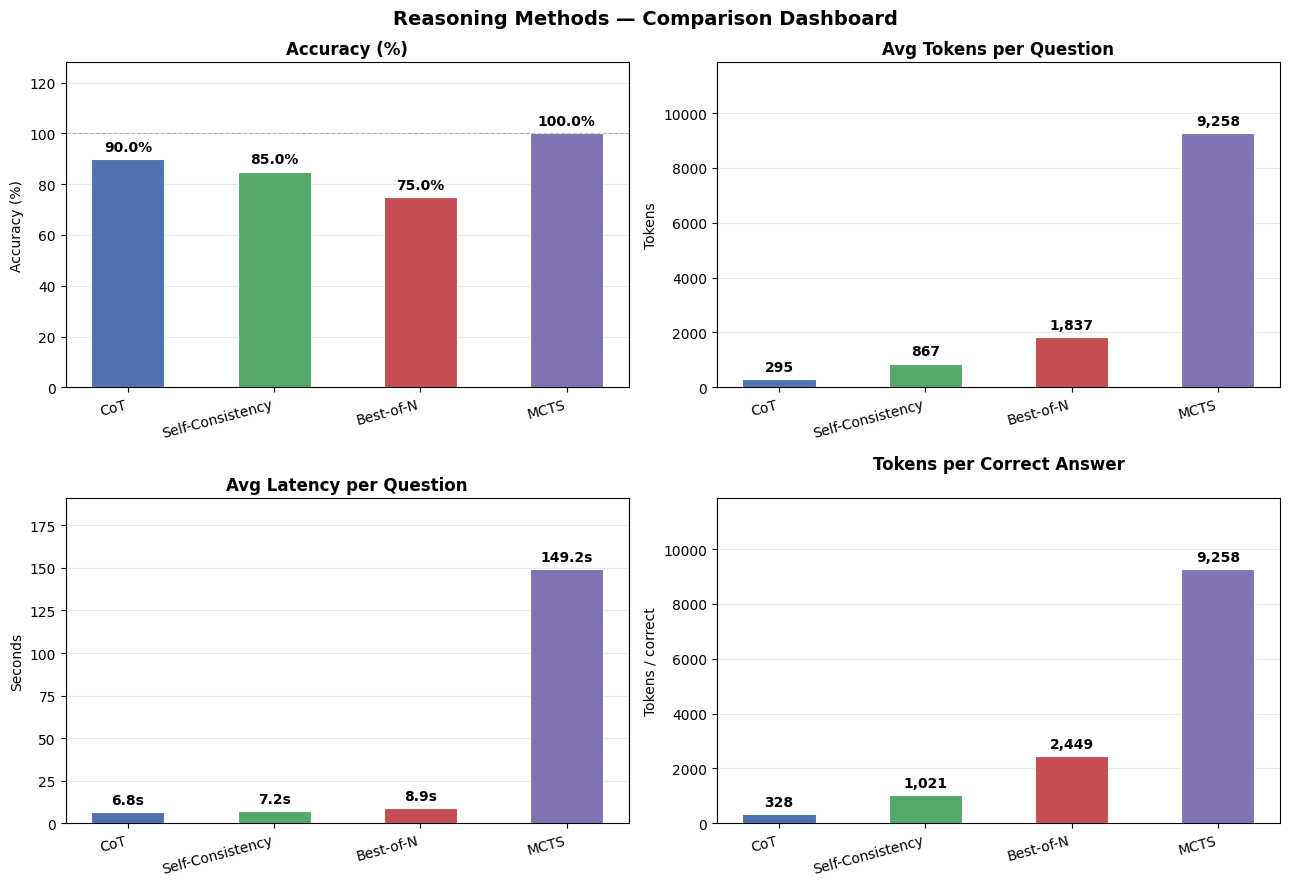

In [381]:
COLORS = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
methods = df_stats['method'].tolist()
x = np.arange(len(methods))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Reasoning Methods — Comparison Dashboard', fontsize=14, fontweight='bold')

def bar_chart(ax, values, title, ylabel, fmt_fn=lambda v: f'{v:.0f}'):
    bars = ax.bar(x, values, color=COLORS, width=0.5, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    ymax = max(values) if max(values) > 0 else 1
    ax.set_ylim(0, ymax * 1.28)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + ymax * 0.02,
                fmt_fn(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

bar_chart(axes[0,0], (df_stats['accuracy']*100).tolist(),
          'Accuracy (%)', 'Accuracy (%)', fmt_fn=lambda v: f'{v:.1f}%')
axes[0,0].axhline(df_stats['accuracy'].max()*100, color='gray',
                   linestyle='--', linewidth=0.8, alpha=0.5)

bar_chart(axes[0,1], df_stats['avg_tokens'].tolist(),
          'Avg Tokens per Question', 'Tokens', fmt_fn=lambda v: f'{int(v):,}')

bar_chart(axes[1,0], df_stats['avg_latency'].tolist(),
          'Avg Latency per Question', 'Seconds', fmt_fn=lambda v: f'{v:.1f}s')

bar_chart(axes[1,1], df_stats['tok_per_correct'].tolist(),
          'Tokens per Correct Answer\n',
          'Tokens / correct', fmt_fn=lambda v: f'{int(v):,}')

plt.tight_layout()
plt.savefig('comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

### Per-Question Correctness Heatmap


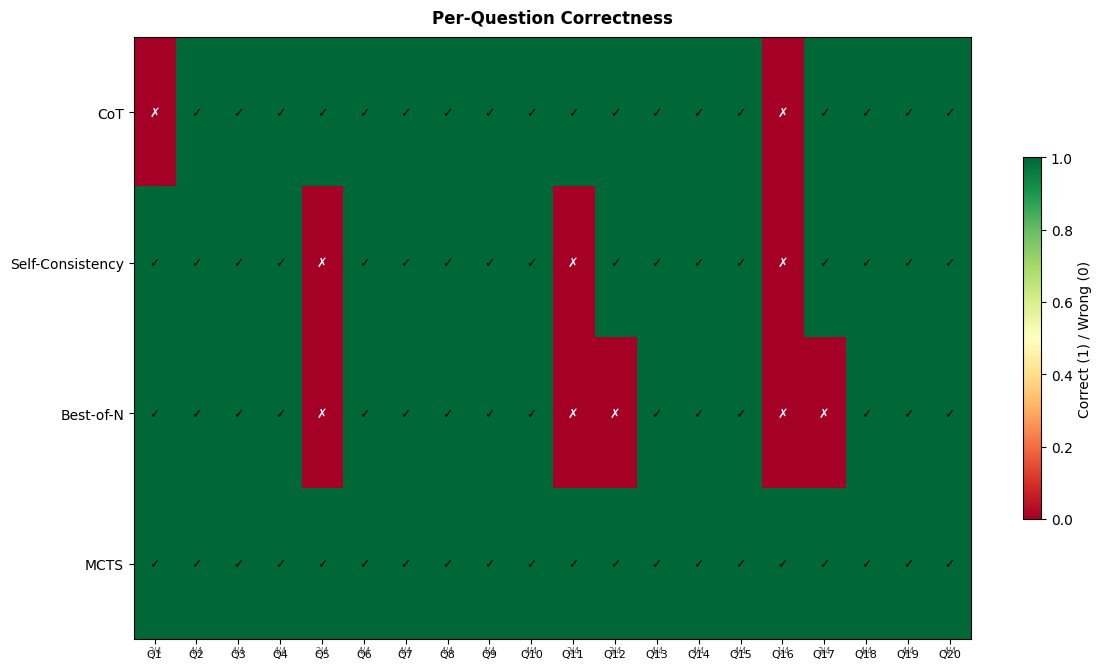

In [382]:
n_questions = len(df_test)
n_methods = 4

fig_width = min(max(10, n_questions * 0.6), 30)
fig_height = n_methods * 1.2 + 2

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

method_results = {
    'CoT':              [r['correct'] for r in results_cot],
    'Self-Consistency': [r['correct'] for r in results_sc],
    'Best-of-N':        [r['correct'] for r in results_bon],
    'MCTS':             [r['correct'] for r in results_mcts],
}
matrix = np.array(list(method_results.values()), dtype=float)

im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(n_questions))

if n_questions <= 40:
    ax.set_xticklabels([f'Q{i+1}' for i in range(n_questions)], fontsize=8)
else:
    labels = [f'Q{i+1}' if i % 5 == 0 else '' for i in range(n_questions)]
    ax.set_xticklabels(labels, fontsize=8)

ax.set_yticks(range(n_methods))
ax.set_yticklabels(list(method_results.keys()), fontsize=10)
ax.set_title('Per-Question Correctness', fontweight='bold', pad=10)

cell_width = fig_width / n_questions
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        if cell_width > 0.3:
            ax.text(j, i, '✓' if matrix[i, j] else '✗',
                    ha='center', va='center', fontsize=9, fontweight='bold',
                    color='white' if matrix[i, j] == 0 else 'black')

plt.colorbar(im, ax=ax, label='Correct (1) / Wrong (0)', shrink=0.6)

if n_questions <= 60:
    for j, s in enumerate(matrix.sum(axis=0)):
        ax.text(j, n_methods - 0.4, f'{int(s)}/{n_methods}',
                ha='center', va='bottom', fontsize=6, color='#555')

plt.tight_layout()
plt.savefig('correctness_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Accuracy vs Token Cost — The Tradeoff


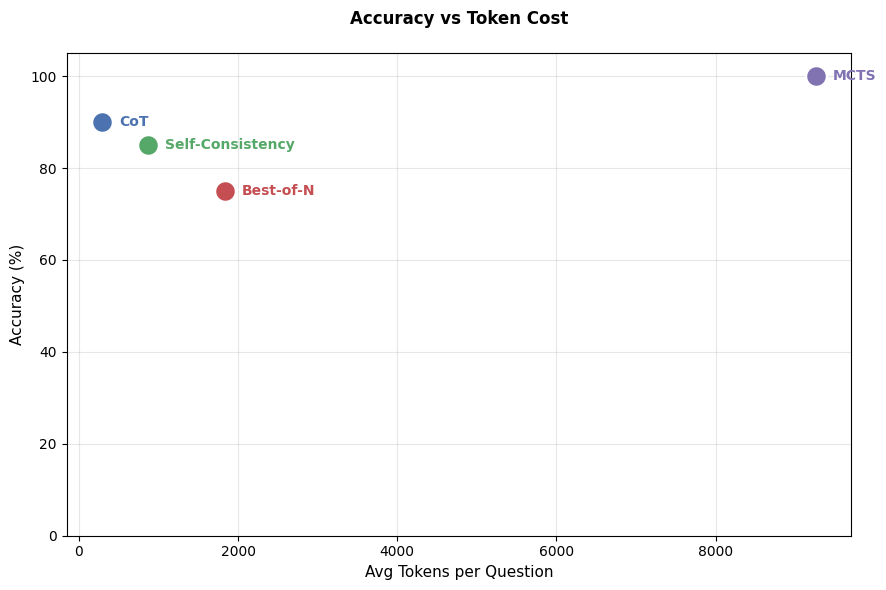

In [383]:
fig, ax = plt.subplots(figsize=(9, 6))

for i, row in df_stats.iterrows():
    ax.scatter(row['avg_tokens'], row['accuracy']*100,
               color=COLORS[i], s=220, zorder=5, edgecolor='white', linewidth=1.5)
    ax.annotate(row['method'],
                xy=(row['avg_tokens'], row['accuracy']*100),
                xytext=(12, 0), textcoords='offset points',
                fontsize=10, fontweight='bold', color=COLORS[i], va='center')

ax.set_xlabel('Avg Tokens per Question', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Accuracy vs Token Cost\n', fontweight='bold')
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_vs_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary & Insights

### Method Comparison

| Method | Strengths | Weaknesses |
|---|---|---|
| **CoT** | Fast, cheap, often sufficient | One bad step → wrong chain, no backtracking |
| **Self-Consistency** | Robust to random errors | Systematic errors not fixed by voting |
| **Best-of-N** | Handles diverse answer space | LLM self-scoring has bias |
| **MCTS** | Strategic search, reuses partial reasoning | Higher latency and token cost |

### When Does MCTS Help?
- **Multi-step problems with false starts** — can backtrack and explore alternative paths
- **Problems where first intuition is wrong** — exploration finds alternatives CoT misses
- **Larger iteration/compute budgets** — more search iterations → better coverage

### Fairness Note
Raw accuracy comparison is **misleading** without controlling for token budget. The **accuracy-vs-token-cost scatter** and **tokens-per-correct-answer** are the honest metrics.


### Important Distinction: System-Level vs. Model-Level Reasoning
It is crucial to understand that the methods demonstrated in this notebook (CoT, MCTS, Best-of-N) are forms of System-Level Scaffolding.

- What we did here: We took a standard, non-reasoning LLM and wrote external Python code to force it to generate steps, vote, or build a search tree. The "thinking" happens in the visible output tokens and is managed by our code.

- What this is NOT: This is not the same as native "Thinking Models" (e.g., OpenAI o1, DeepSeek-R1). Those models are trained using Reinforcement Learning (RL) to natively perform complex reasoning in a hidden latent space before outputting an answer. Their ability to backtrack, verify, and correct is baked into their neural network weights, not controlled by an external Python script.

- Takeaway: Wrapping a standard LLM in MCTS simulates the behavior of advanced reasoning models, allowing us to boost the performance of smaller/standard models, but at a high API token and latency cost.

## Conclusions on Reasoning Mechanisms

- ### The Trade-off between 'Reflex' and 'Reasoning'
  At their core, all large language models are predictive systems. By applying MCTS, we are shifting the model from a **"fast reflex"** state (System 1) to a **"slow thinking"** state (System 2). This does not alter the internal architecture of the model; rather, it fundamentally changes how we extract and leverage its computational power.

- ### The Evaluator (The Bottleneck)
  A significant hurdle in implementing this system is the capacity for self-assessment. In real-world production environments, maximum efficiency is typically achieved by using a specialized **Reward Model (RM)** or **Process Reward Model (PRM)**.

  In this notebook, we are pushing the model's limits by forcing it to grade its own work—a process that demands a level of logical rigor that models may not consistently achieve without the algorithmic constraints imposed by the search process.

- ### The Cost of Precision
  Forcing the model to "think" through multiple MCTS iterations effectively eliminates "hallucinated" or careless errors, but it comes at the price of significantly higher resource consumption. This reinforces a key insight:

> **AI intelligence is not solely determined by its parameters, but also by the protocol and procedural rigor we compel it to follow during inference.**